**Author:** Steve Landry Ndjock 

**Version:** 1.0

**Python version:**  3.x

In [67]:
%matplotlib inline

# Core libraries
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif, f_regression
from sklearn.experimental import enable_iterative_imputer

from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=UserWarning)


# Data Preparation

In [68]:
df_original = pd.read_csv("cmi_internet_WT_outlier_New_features.csv")
df = df_original.copy()

In [69]:
def encoder_labels_categoriques(df):
    """
    Prend un DataFrame en entrée, convertit les variables catégoriques 
    en nombres entiers (0, 1, 2, 3...) dans la même colonne, et retourne le DataFrame.
    """
    # 1. Copier le dataset pour éviter de modifier l'original
    df_encode = df.copy()
    
    # 2. Identifier les colonnes contenant du texte
    colonnes_categoriques = df_encode.select_dtypes(include=['object', 'category']).columns.tolist()
    
    if not colonnes_categoriques:
        print("Aucune colonne catégorique trouvée.")
        return df_encode
    
    # 3. Remplacer le texte par des codes numériques
    for colonne in colonnes_categoriques:
        # Convertit en type catégorie, puis récupère les codes numériques
        df_encode[colonne] = df_encode[colonne].astype('category').cat.codes
        
    return df_encode

In [70]:
df = encoder_labels_categoriques(df)

In [71]:
df.drop(columns=["PCIAT-PCIAT_Total", "sii"], inplace=True)

In [72]:
X = df.values
y = np.array(df_original.loc[df.index, 'sii'])

In [73]:
df.head()

,Basic_Demos-Enroll_Season,Basic_Demos-Age,Basic_Demos-Sex,CGAS-Season,CGAS-CGAS_Score,Physical-Season,Physical-Height,Physical-Weight,Physical-Waist_Circumference,Physical-Diastolic_BP,...,SDS-Season,SDS-SDS_Total_Raw,SDS-SDS_Total_T,PreInt_EduHx-Season,PreInt_EduHx-computerinternet_hoursday,Physical-BMI_New,FGC_SitReach_Avg,FGC_Grip_Avg,PAQ_Total,Endurance_Total_Sec
0,0,5.0,0.0,3,51.00,0,46.000,50.8,26.0,73.9,...,0,50.55,71.8,0,3,16.877316,6.5,12.3225,2.006,448.0
1,2,9.0,0.0,1,62.55,0,48.000,46.0,22.0,75.0,...,0,46.00,64.0,2,0,14.035590,11.0,20.6250,2.010,334.0
2,2,10.0,1.0,0,71.00,0,56.500,75.6,25.4,65.0,...,0,38.00,54.0,2,2,16.648696,10.0,12.4500,2.009,453.0
3,3,9.0,0.0,0,71.00,2,56.000,81.6,26.0,60.0,...,2,31.00,45.0,3,0,18.292347,7.0,20.6250,2.010,577.0
4,1,18.0,1.0,2,65.00,1,55.003,77.0,26.0,68.0,...,0,41.60,61.4,1,1,17.894545,9.1,21.5525,1.040,460.0


# Data Partitioning

In [74]:
from sklearn.model_selection import train_test_split, cross_val_score 

from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.metrics import roc_curve, auc, roc_auc_score

In [75]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, 
                                                    random_state=100, stratify=y)

In [76]:
X_train.shape

(5922, 83)

# Classification

In [77]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_curve, auc, roc_auc_score
from scikitplot.metrics import plot_roc
from sklearn.metrics import classification_report, f1_score, confusion_matrix, ConfusionMatrixDisplay 

In [78]:
clf = DecisionTreeClassifier(min_samples_leaf=3, random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred, digits=3))

Accuracy 0.8821907013396375
F1-score [0.93879641 0.69753086 0.68020305 0.        ]
              precision    recall  f1-score   support

           0      0.935     0.942     0.939      1945
           1      0.708     0.688     0.698       493
           2      0.677     0.684     0.680        98
           3      0.000     0.000     0.000         2

    accuracy                          0.882      2538
   macro avg      0.580     0.578     0.579      2538
weighted avg      0.880     0.882     0.881      2538



> The Decision Tree classifier achieves **88.2% overall accuracy**, driven by strong performance on the majority class (*None*, F1=0.939). However, the model **fails entirely on class 3** (*Severe*, F1=0.000), due to extreme class imbalance — only 2 test samples represent this category. To address this, we apply `class_weight='balanced'` and **SMOTE oversampling** on the training set only, ensuring the minority classes (*Moderate*, *Severe*) are better represented without introducing **data leakage** into the evaluation.

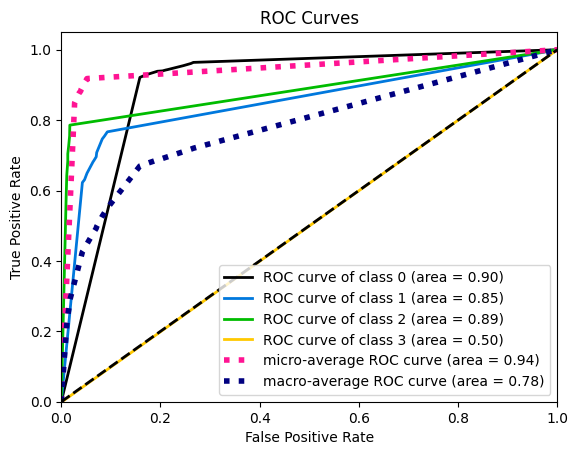

In [79]:
y_score = clf.predict_proba(X_test)
plot_roc(y_test, y_score)
plt.show()

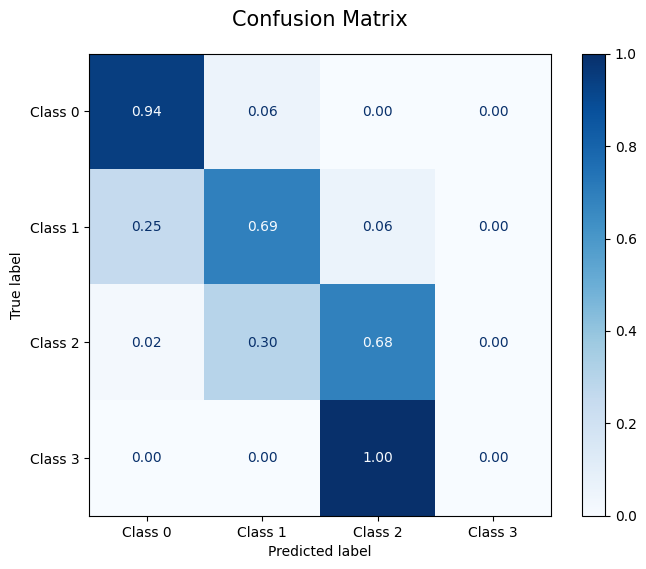

In [80]:
# 1. Crea la figura
fig, ax = plt.subplots(figsize=(8, 6))

# 2. Usa 'normalize=true' per vedere le percentuali per riga
# Usiamo 'Blues' o 'Viridis' per una migliore leggibilità
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    display_labels=["Class 0", "Class 1", "Class 2", "Class 3"], # Opzionale: nomi reali
    cmap=plt.cm.Blues,
    normalize='true', 
    ax=ax,
    values_format='.2f' # Mostra solo 2 decimali
)

# 3. Personalizzazione estetica
ax.set_title("Confusion Matrix", fontsize=15, pad=20)
plt.grid(False) # Rimuove linee fastidiose se presenti
plt.show()

# Feature Selection

## Variance Threshold

In [81]:
np.histogram(np.var(X_train, axis=0)[np.var(X_train, axis=0) < 3.14e04])

(array([79,  1,  0,  0,  0,  0,  0,  0,  0,  1], dtype=int64),
 array([7.44006382e-02, 6.71414954e+02, 1.34275551e+03, 2.01409606e+03,
        2.68543662e+03, 3.35677717e+03, 4.02811772e+03, 4.69945828e+03,
        5.37079883e+03, 6.04213939e+03, 6.71347994e+03]))

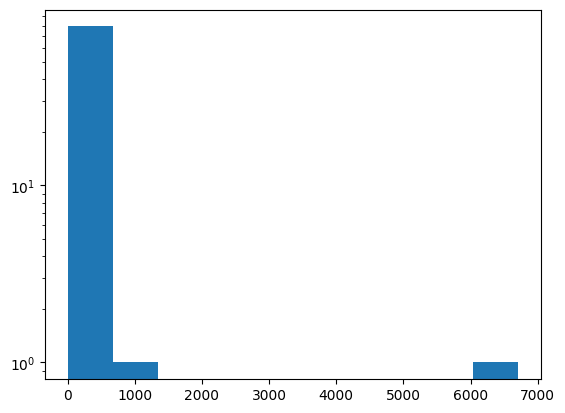

In [82]:
plt.hist(np.var(X_train, axis=0)[np.var(X_train, axis=0) < 3.14e04])
plt.yscale('log')
plt.show()

In [17]:
from sklearn.feature_selection import VarianceThreshold

In [18]:
(.8 * (1 - .8))

0.15999999999999998

In [83]:
sel = VarianceThreshold(threshold=(.8 * (1 - .8)))
X_train_sel = sel.fit_transform(X_train)

X_train_sel.shape

(5922, 77)

In [84]:
X_train.shape

(5922, 83)

In [85]:
X_test_sel = sel.transform(X_test)

clf = DecisionTreeClassifier(min_samples_leaf=3, random_state=42)
clf.fit(X_train_sel, y_train)

y_pred = clf.predict(X_test_sel)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred, digits=3))

Accuracy 0.8778565799842396
F1-score [0.93624679 0.68958544 0.67692308 0.        ]
              precision    recall  f1-score   support

           0      0.936     0.936     0.936      1945
           1      0.688     0.692     0.690       493
           2      0.680     0.673     0.677        98
           3      0.000     0.000     0.000         2

    accuracy                          0.878      2538
   macro avg      0.576     0.575     0.576      2538
weighted avg      0.877     0.878     0.878      2538



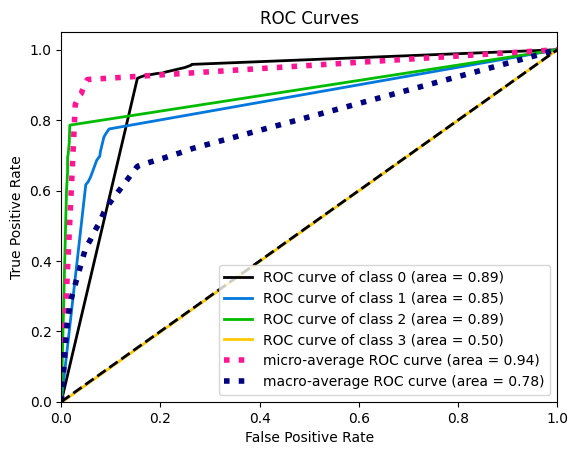

In [86]:
y_score = clf.predict_proba(X_test_sel)
plot_roc(y_test, y_score)
plt.show()

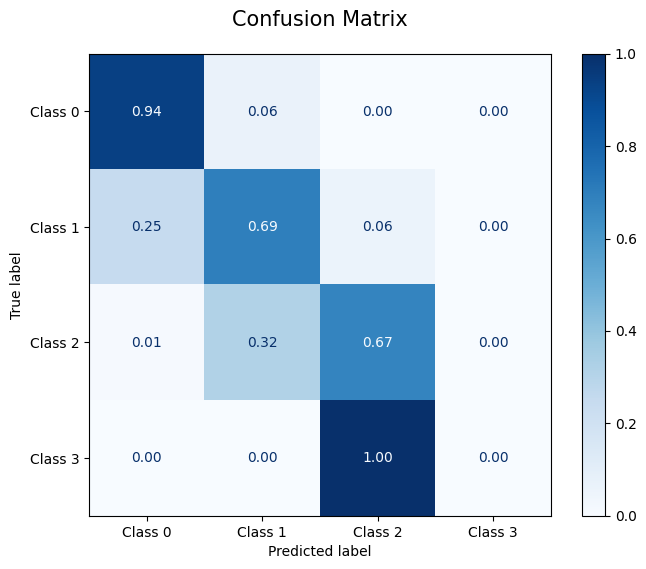

In [87]:
# 1. Crea la figura
fig, ax = plt.subplots(figsize=(8, 6))

# 2. Usa 'normalize=true' per vedere le percentuali per riga
# Usiamo 'Blues' o 'Viridis' per una migliore leggibilità
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    display_labels=["Class 0", "Class 1", "Class 2", "Class 3"], # Opzionale: nomi reali
    cmap=plt.cm.Blues,
    normalize='true', 
    ax=ax,
    values_format='.2f' # Mostra solo 2 decimali
)

# 3. Personalizzazione estetica
ax.set_title("Confusion Matrix", fontsize=15, pad=20)
plt.grid(False) # Rimuove linee fastidiose se presenti
plt.show()

## Univariate Feature Selection

In [24]:
from sklearn.feature_selection import SelectKBest

In [88]:
sel = SelectKBest(k=40, score_func=f_classif)
X_train_sel = sel.fit_transform(X_train, y_train)

X_train_sel.shape

(5922, 40)

In [89]:
sel.scores_

array([9.62632912e-02, 2.59921770e+01, 7.72119765e+00, 4.85354671e-01,
       1.81535917e+01, 6.20099364e+00, 3.78474991e+01, 3.06898609e+01,
       1.31204524e+01, 1.19174875e+01, 2.23560442e+00, 2.54236145e+01,
       2.49757811e+00, 9.71566215e-01, 2.27274919e-01, 7.22998018e-01,
       2.63278166e+00, 4.13275705e+01, 3.85048154e+00, 5.71425624e+00,
       5.67184896e+00, 3.96811618e+00, 3.93811725e+00, 3.03362532e+01,
       1.02253680e+01, 4.31204489e-01, 3.84565540e+00, 3.37822571e+00,
       2.11831039e+00, 7.13797076e+00, 4.53481127e+00, 2.39925316e+00,
       4.58378656e-01, 5.31444033e+00, 1.35092628e+01, 1.90608390e+01,
       2.92788205e+01, 1.93796100e+01, 1.99969359e+01, 1.85877652e+01,
       8.79863095e+00, 1.55396264e+01, 8.06500680e+00, 3.13679430e+01,
       1.47308237e+01, 2.42451361e+01, 2.16615101e+01, 2.97213069e+01,
       1.16782917e+01, 8.25369895e+00, 7.50007321e+00, 3.48109008e+00,
       8.72000773e-01, 9.22352523e+02, 9.92270494e+02, 1.26361165e+03,
      

In [90]:
X_test_sel = sel.transform(X_test)

clf = DecisionTreeClassifier(min_samples_leaf=3, random_state=42)
clf.fit(X_train_sel, y_train)

y_pred = clf.predict(X_test_sel)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred, digits=3))

Accuracy 0.8983451536643026
F1-score [0.94720577 0.74371859 0.7244898  0.        ]
              precision    recall  f1-score   support

           0      0.949     0.946     0.947      1945
           1      0.737     0.751     0.744       493
           2      0.724     0.724     0.724        98
           3      0.000     0.000     0.000         2

    accuracy                          0.898      2538
   macro avg      0.603     0.605     0.604      2538
weighted avg      0.898     0.898     0.898      2538



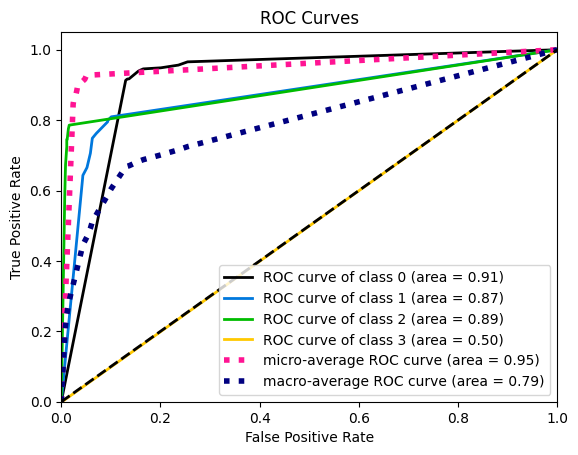

In [91]:
y_score = clf.predict_proba(X_test_sel)
plot_roc(y_test, y_score)
plt.show()

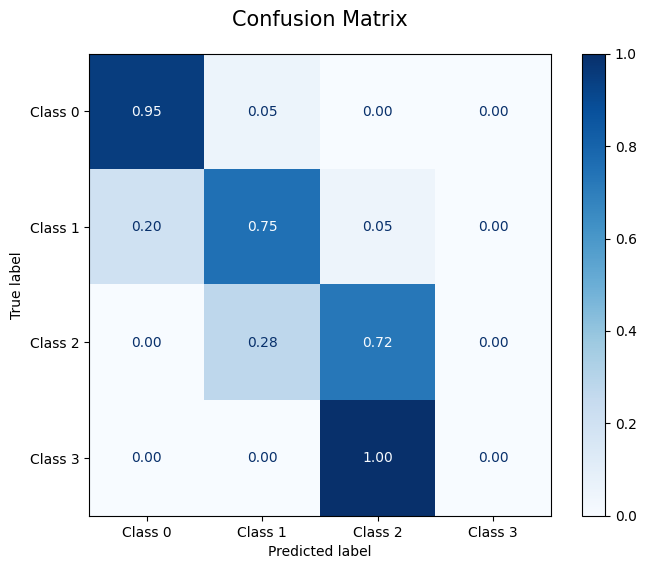

In [92]:
# 1. Crea la figura
fig, ax = plt.subplots(figsize=(8, 6))

# 2. Usa 'normalize=true' per vedere le percentuali per riga
# Usiamo 'Blues' o 'Viridis' per una migliore leggibilità
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    display_labels=["Class 0", "Class 1", "Class 2", "Class 3"], # Opzionale: nomi reali
    cmap=plt.cm.Blues,
    normalize='true', 
    ax=ax,
    values_format='.2f' # Mostra solo 2 decimali
)

# 3. Personalizzazione estetica
ax.set_title("Confusion Matrix", fontsize=15, pad=20)
plt.grid(False) # Rimuove linee fastidiose se presenti
plt.show()

## Recursive Feature Elimination (RFE)

In [30]:
from sklearn.feature_selection import RFE

In [93]:
sel = RFE(DecisionTreeClassifier(), n_features_to_select=4)
X_train_sel = sel.fit_transform(X_train, y_train)
X_train_sel.shape

(5922, 4)

In [94]:
X_test_sel = sel.transform(X_test)

clf = DecisionTreeClassifier(min_samples_leaf=3, random_state=42)
clf.fit(X_train_sel, y_train)

y_pred = clf.predict(X_test_sel)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred, digits=3))

Accuracy 0.8396375098502759
F1-score [0.91624365 0.57663451 0.56716418 0.        ]
              precision    recall  f1-score   support

           0      0.905     0.928     0.916      1945
           1      0.611     0.546     0.577       493
           2      0.553     0.582     0.567        98
           3      0.000     0.000     0.000         2

    accuracy                          0.840      2538
   macro avg      0.517     0.514     0.515      2538
weighted avg      0.833     0.840     0.836      2538



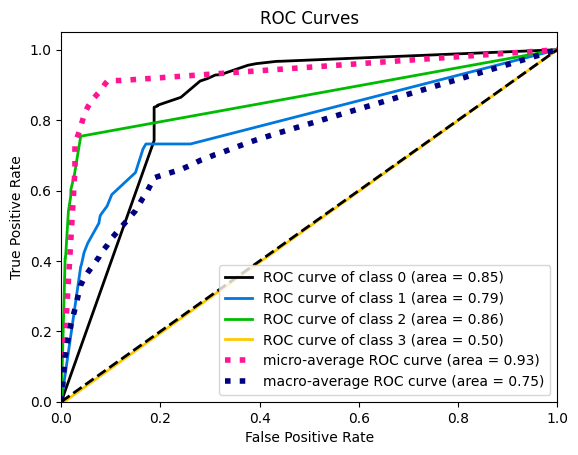

In [95]:
y_score = clf.predict_proba(X_test_sel)
plot_roc(y_test, y_score)
plt.show()

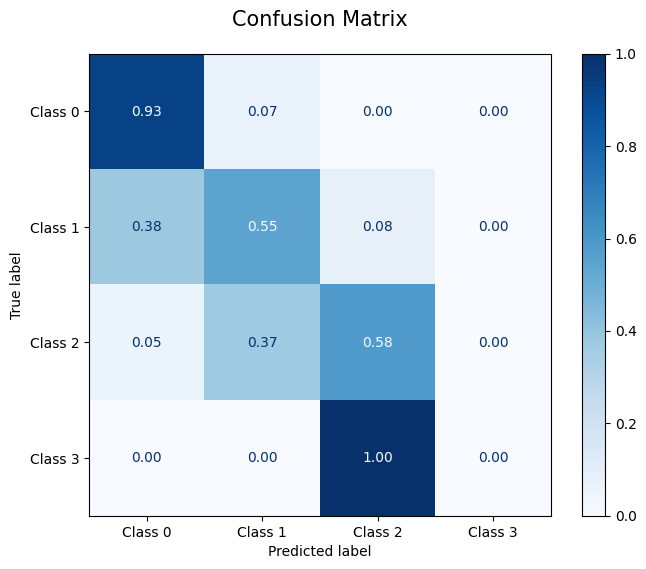

In [96]:
# 1. Crea la figura
fig, ax = plt.subplots(figsize=(8, 6))

# 2. Usa 'normalize=true' per vedere le percentuali per riga
# Usiamo 'Blues' o 'Viridis' per una migliore leggibilità
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    display_labels=["Class 0", "Class 1", "Class 2", "Class 3"], # Opzionale: nomi reali
    cmap=plt.cm.Blues,
    normalize='true', 
    ax=ax,
    values_format='.2f' # Mostra solo 2 decimali
)

# 3. Personalizzazione estetica
ax.set_title("Confusion Matrix", fontsize=15, pad=20)
plt.grid(False) # Rimuove linee fastidiose se presenti
plt.show()

## Select Form Model
Meta-transformer for selecting features based on importance weights.

In [97]:
from sklearn.feature_selection import SelectFromModel

In [98]:
sel = SelectFromModel(DecisionTreeClassifier())
X_train_sel = sel.fit_transform(X_train, y_train)
X_train_sel.shape

(5922, 16)

In [99]:
X_test_sel = sel.transform(X_test)

clf = DecisionTreeClassifier(min_samples_leaf=3, random_state=42)
clf.fit(X_train_sel, y_train)

y_pred = clf.predict(X_test_sel)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred, digits=3))

Accuracy 0.9062253743104807
F1-score [0.95235669 0.75262055 0.73846154 0.        ]
              precision    recall  f1-score   support

           0      0.944     0.961     0.952      1945
           1      0.779     0.728     0.753       493
           2      0.742     0.735     0.738        98
           3      0.000     0.000     0.000         2

    accuracy                          0.906      2538
   macro avg      0.616     0.606     0.611      2538
weighted avg      0.903     0.906     0.905      2538



In [100]:
# 1. Get the boolean mask (True for kept features, False for removed)
mask = sel.get_support()

# 2. Apply this mask to your ORIGINAL column names
# Replace 'df' with the name of your original DataFrame
original_feature_names = df.columns
real_feature_names = original_feature_names[mask]

# 3. Create the cleaned-up importance table
feature_importance_df = pd.DataFrame({
    'Feature': real_feature_names,
    'Importance': clf.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(feature_importance_df)

           Feature  Importance
3   PCIAT-PCIAT_05    0.400287
10  PCIAT-PCIAT_15    0.114323
12  PCIAT-PCIAT_17    0.065529
2   PCIAT-PCIAT_03    0.055981
14  PCIAT-PCIAT_19    0.042939
4   PCIAT-PCIAT_07    0.040201
13  PCIAT-PCIAT_18    0.035901
7   PCIAT-PCIAT_11    0.035197
0   PCIAT-PCIAT_01    0.032303
9   PCIAT-PCIAT_14    0.029061
8   PCIAT-PCIAT_13    0.027875
5   PCIAT-PCIAT_09    0.027860
11  PCIAT-PCIAT_16    0.027824
6   PCIAT-PCIAT_10    0.023891
15  PCIAT-PCIAT_20    0.021739
1   PCIAT-PCIAT_02    0.019088


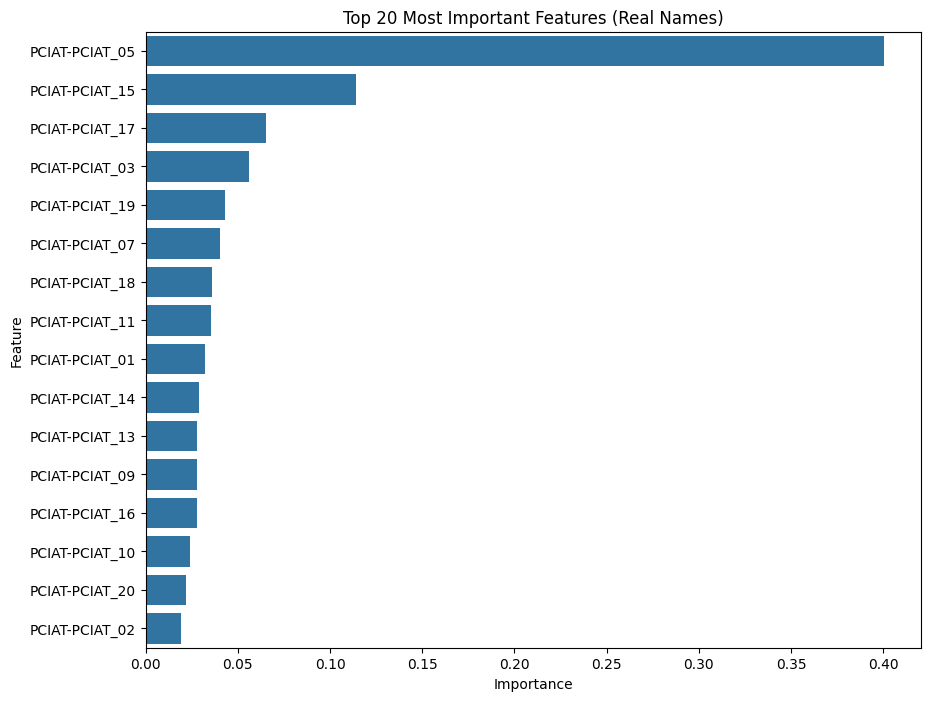

In [101]:
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(20))
plt.title('Top 20 Most Important Features (Real Names)')
plt.show()

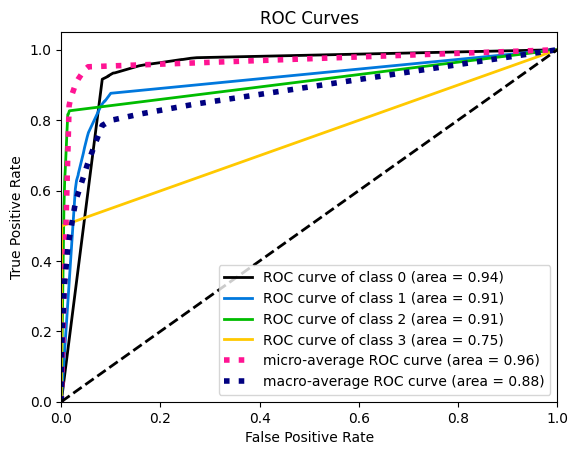

In [102]:
y_score = clf.predict_proba(X_test_sel)
plot_roc(y_test, y_score)
plt.show()

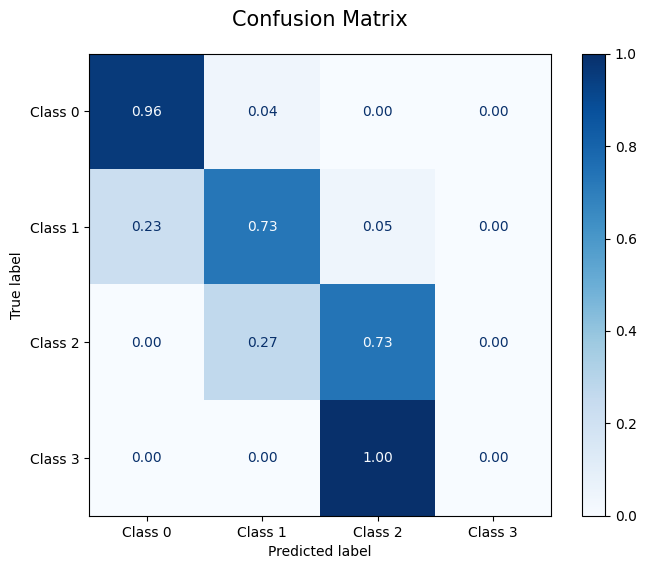

In [103]:
# 1. Crea la figura
fig, ax = plt.subplots(figsize=(8, 6))

# 2. Usa 'normalize=true' per vedere le percentuali per riga
# Usiamo 'Blues' o 'Viridis' per una migliore leggibilità
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    display_labels=["Class 0", "Class 1", "Class 2", "Class 3"], # Opzionale: nomi reali
    cmap=plt.cm.Blues,
    normalize='true', 
    ax=ax,
    values_format='.2f' # Mostra solo 2 decimali
)

# 3. Personalizzazione estetica
ax.set_title("Confusion Matrix", fontsize=15, pad=20)
plt.grid(False) # Rimuove linee fastidiose se presenti
plt.show()

### Gradient Boosting

In [104]:
import xgboost as xgb

In [105]:
sel = SelectFromModel(xgb.XGBClassifier(random_state=42))
X_train_sel = sel.fit_transform(X_train, y_train)
X_train_sel.shape

(5922, 19)

In [106]:
X_test_sel = sel.transform(X_test)

clf = DecisionTreeClassifier(min_samples_leaf=3, random_state=42)
clf.fit(X_train_sel, y_train)

y_pred = clf.predict(X_test_sel)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred, digits=3))

Accuracy 0.9078014184397163
F1-score [0.94973207 0.75912409 0.80612245 0.        ]
              precision    recall  f1-score   support

           0      0.943     0.957     0.950      1945
           1      0.781     0.738     0.759       493
           2      0.806     0.806     0.806        98
           3      0.000     0.000     0.000         2

    accuracy                          0.908      2538
   macro avg      0.632     0.625     0.629      2538
weighted avg      0.905     0.908     0.906      2538



In [107]:
# Access the fitted XGBoost model from the selector
trained_xgb = sel.estimator_

# Get importance (Gain represents the improvement in accuracy brought by a feature)
importance = trained_xgb.get_booster().get_score(importance_type='gain')

# Sort and print for better readability
sorted_importance = sorted(importance.items(), key=lambda x: x[1], reverse=True)
print(sorted_importance)

[('f70', 16.917118072509766), ('f57', 11.256587982177734), ('f67', 10.321066856384277), ('f69', 7.576447486877441), ('f55', 5.740878582000732), ('f54', 2.7727129459381104), ('f71', 2.441699743270874), ('f61', 2.000091075897217), ('f60', 1.902217149734497), ('f65', 1.88202702999115), ('f66', 1.878479242324829), ('f62', 1.7816511392593384), ('f53', 1.758007526397705), ('f59', 1.7020230293273926), ('f63', 1.6167999505996704), ('f58', 1.606868863105774), ('f48', 1.6056180000305176), ('f72', 1.5651025772094727), ('f64', 1.3149288892745972), ('f68', 1.1211122274398804), ('f56', 0.9380298256874084), ('f45', 0.7303517460823059), ('f7', 0.6584384441375732), ('f27', 0.6186329126358032), ('f6', 0.6047857403755188), ('f77', 0.6028018593788147), ('f1', 0.5856072902679443), ('f17', 0.5776467323303223), ('f19', 0.5486040115356445), ('f34', 0.5180245041847229), ('f15', 0.516477108001709), ('f36', 0.4766339361667633), ('f11', 0.45682647824287415), ('f21', 0.4496959149837494), ('f44', 0.4389217495918274

In [108]:
original_cols = df.columns 

# Apply the mask to get only the features the selector kept
selected_names = original_cols[sel.get_support()]

# Create the table
dt_importance = pd.DataFrame({
    'Feature': selected_names,
    'Importance': clf.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("--- Decision Tree Importance ---")
print(dt_importance.head(20))

--- Decision Tree Importance ---
           Feature  Importance
4   PCIAT-PCIAT_05    0.391645
14  PCIAT-PCIAT_15    0.117969
15  PCIAT-PCIAT_17    0.066716
3   PCIAT-PCIAT_03    0.055481
17  PCIAT-PCIAT_19    0.038562
16  PCIAT-PCIAT_18    0.037860
6   PCIAT-PCIAT_07    0.035236
18  PCIAT-PCIAT_20    0.032504
10  PCIAT-PCIAT_11    0.031277
13  PCIAT-PCIAT_14    0.026067
12  PCIAT-PCIAT_13    0.024916
5   PCIAT-PCIAT_06    0.022862
1   PCIAT-PCIAT_01    0.022206
8   PCIAT-PCIAT_09    0.021335
2   PCIAT-PCIAT_02    0.019537
9   PCIAT-PCIAT_10    0.019338
11  PCIAT-PCIAT_12    0.017270
7   PCIAT-PCIAT_08    0.014936
0     PAQ_A-Season    0.004282


In [109]:
importance_dict = trained_xgb.get_booster().get_score(importance_type='gain')

# 2. Map 'f#' to the column name at that index
# We use the original_cols list we defined above
real_names_dict = {}
for f_code, score in importance_dict.items():
    index = int(f_code.replace('f', ''))
    name = original_cols[index]
    real_names_dict[name] = score

# 3. Create the sorted table
xgb_importance = pd.DataFrame({
    'Feature': list(real_names_dict.keys()),
    'Gain': list(real_names_dict.values())
}).sort_values(by='Gain', ascending=False)

print("\n--- XGBoost Importance (Gain) ---")
print(xgb_importance.head(10))


--- XGBoost Importance (Gain) ---
           Feature       Gain
70  PCIAT-PCIAT_18  16.917118
57  PCIAT-PCIAT_05  11.256588
67  PCIAT-PCIAT_15  10.321067
69  PCIAT-PCIAT_17   7.576447
55  PCIAT-PCIAT_03   5.740879
54  PCIAT-PCIAT_02   2.772713
71  PCIAT-PCIAT_19   2.441700
61  PCIAT-PCIAT_09   2.000091
60  PCIAT-PCIAT_08   1.902217
65  PCIAT-PCIAT_13   1.882027


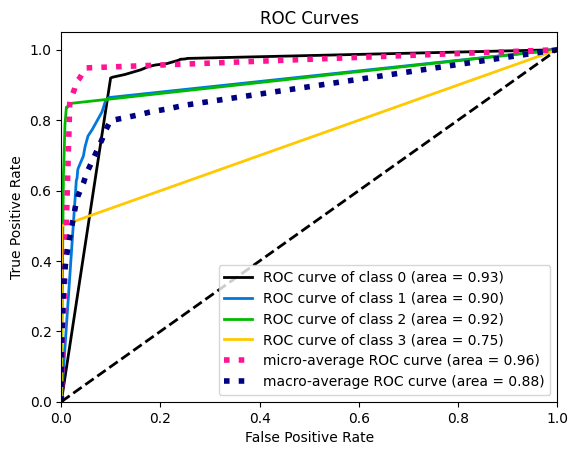

In [110]:
y_score = clf.predict_proba(X_test_sel)
plot_roc(y_test, y_score)
plt.show()

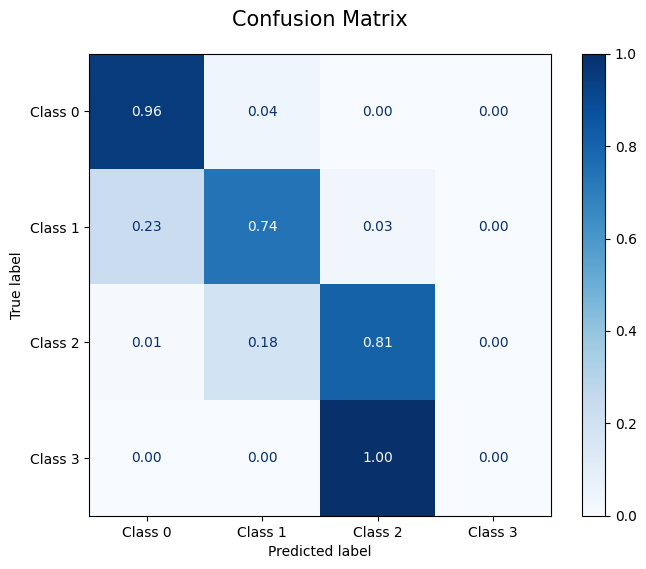

In [111]:
# 1. Crea la figura
fig, ax = plt.subplots(figsize=(8, 6))

# 2. Usa 'normalize=true' per vedere le percentuali per riga
# Usiamo 'Blues' o 'Viridis' per una migliore leggibilità
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    display_labels=["Class 0", "Class 1", "Class 2", "Class 3"], # Opzionale: nomi reali
    cmap=plt.cm.Blues,
    normalize='true', 
    ax=ax,
    values_format='.2f' # Mostra solo 2 decimali
)

# 3. Personalizzazione estetica
ax.set_title("Confusion Matrix", fontsize=15, pad=20)
plt.grid(False) # Rimuove linee fastidiose se presenti
plt.show()

# Feature Projection

## Principal Component Analysis

In [112]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler   

In [113]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [114]:
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

In [115]:
X_train_pca.shape

(5922, 2)

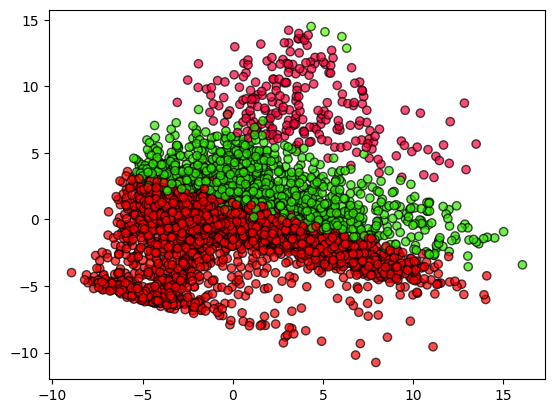

In [116]:
plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, 
            cmap=plt.cm.prism, edgecolor='k', alpha=0.7)
plt.show()

In [117]:
clf = DecisionTreeClassifier(min_samples_leaf=3, random_state=42)
clf.fit(X_train_pca, y_train)

y_pred = clf.predict(X_test_pca)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

Accuracy 0.9519306540583137
F1-score [0.97462189 0.87640449 0.87958115 0.8       ]
              precision    recall  f1-score   support

           0       0.97      0.98      0.97      1945
           1       0.88      0.87      0.88       493
           2       0.90      0.86      0.88        98
           3       0.67      1.00      0.80         2

    accuracy                           0.95      2538
   macro avg       0.86      0.93      0.88      2538
weighted avg       0.95      0.95      0.95      2538



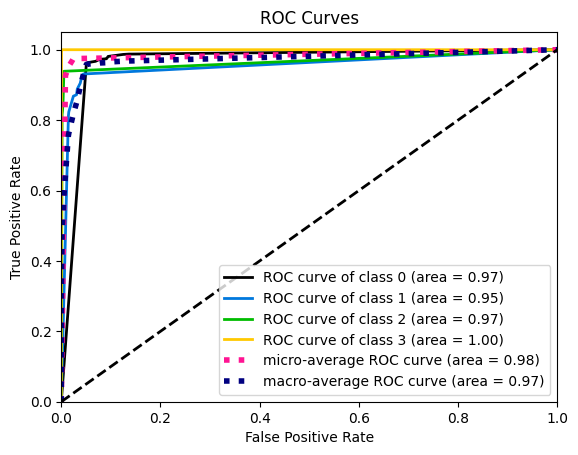

In [118]:
y_score = clf.predict_proba(X_test_pca)
plot_roc(y_test, y_score)
plt.show()

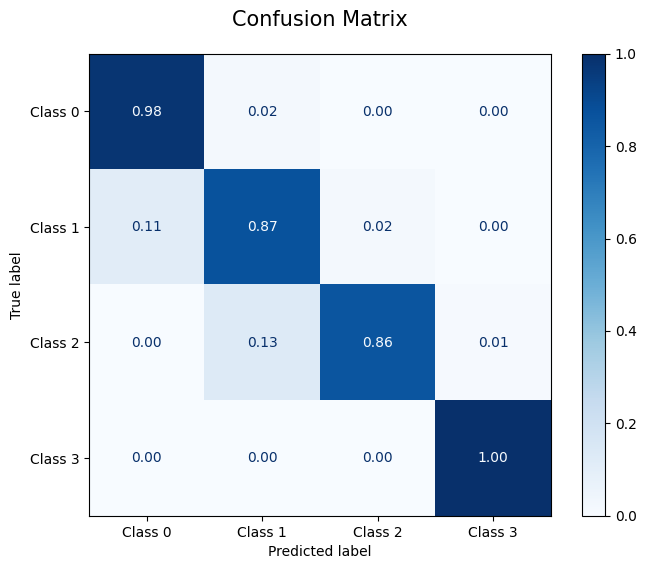

In [119]:
# 1. Crea la figura
fig, ax = plt.subplots(figsize=(8, 6))

# 2. Usa 'normalize=true' per vedere le percentuali per riga
# Usiamo 'Blues' o 'Viridis' per una migliore leggibilità
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    display_labels=["Class 0", "Class 1", "Class 2", "Class 3"], # Opzionale: nomi reali
    cmap=plt.cm.Blues,
    normalize='true', 
    ax=ax,
    values_format='.2f' # Mostra solo 2 decimali
)

# 3. Personalizzazione estetica
ax.set_title("Confusion Matrix", fontsize=15, pad=20)
plt.grid(False) # Rimuove linee fastidiose se presenti
plt.show()

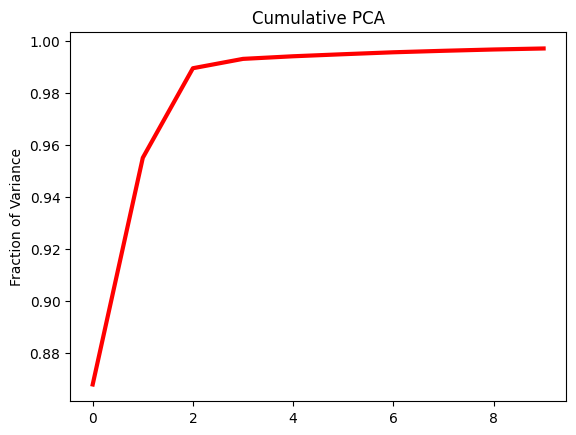

In [120]:
plt.plot(np.cumsum(PCA(n_components=10).fit(X).explained_variance_ratio_), lw=3, color='r', ms=2)
plt.title("Cumulative PCA")
plt.ylabel("Fraction of Variance")
plt.show()

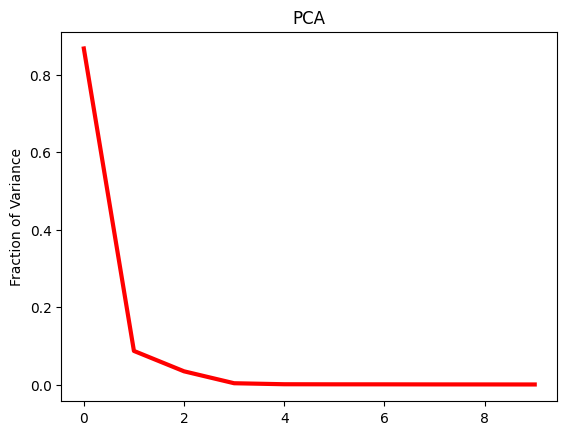

In [121]:
plt.plot(PCA(n_components=10).fit(X).explained_variance_ratio_, lw=3, color='r', ms=2)
plt.title("PCA")
plt.ylabel("Fraction of Variance")
plt.show()

# Random Subspace Projection

In [59]:
from sklearn import random_projection

In [122]:
rsp = random_projection.GaussianRandomProjection(n_components=2, random_state=None)
X_train_rsp = rsp.fit_transform(X_train_scaled)
X_test_rsp = rsp.transform(X_test_scaled)
X_train_rsp.shape

(5922, 2)

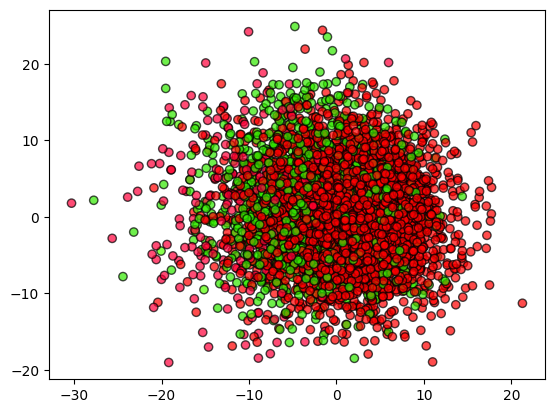

In [123]:
plt.scatter(X_train_rsp[:, 0], X_train_rsp[:, 1], c=y_train, cmap=plt.cm.prism, edgecolor='k', alpha=0.7)
plt.show()

In [124]:
clf = DecisionTreeClassifier(min_samples_leaf=3, random_state=42)
clf.fit(X_train_rsp, y_train)

y_pred = clf.predict(X_test_rsp)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

Accuracy 0.7040977147360126
F1-score [0.8275     0.24534502 0.2484472  0.        ]
              precision    recall  f1-score   support

           0       0.81      0.85      0.83      1945
           1       0.27      0.23      0.25       493
           2       0.32      0.20      0.25        98
           3       0.00      0.00      0.00         2

    accuracy                           0.70      2538
   macro avg       0.35      0.32      0.33      2538
weighted avg       0.68      0.70      0.69      2538



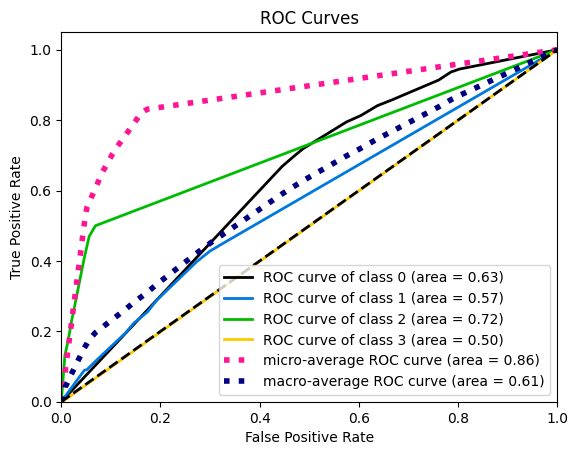

In [125]:
y_score = clf.predict_proba(X_test_rsp)
plot_roc(y_test, y_score)
plt.show()

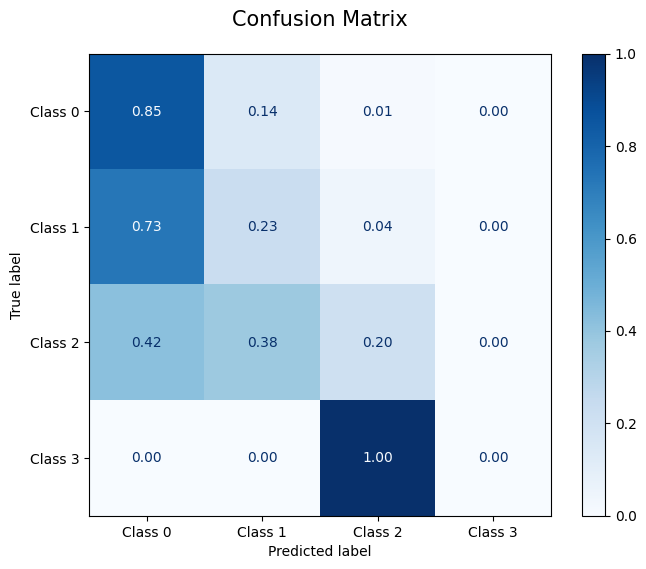

In [126]:
# 1. Crea la figura
fig, ax = plt.subplots(figsize=(8, 6))

# 2. Usa 'normalize=true' per vedere le percentuali per riga
# Usiamo 'Blues' o 'Viridis' per una migliore leggibilità
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    display_labels=["Class 0", "Class 1", "Class 2", "Class 3"], # Opzionale: nomi reali
    cmap=plt.cm.Blues,
    normalize='true', 
    ax=ax,
    values_format='.2f' # Mostra solo 2 decimali
)

# 3. Personalizzazione estetica
ax.set_title("Confusion Matrix", fontsize=15, pad=20)
plt.grid(False) # Rimuove linee fastidiose se presenti
plt.show()

## Multi Dimensional Scaling

In [76]:
from sklearn.manifold import MDS

In [77]:
# Specifichiamo n_init e init per evitare i FutureWarning
mds = MDS(
    n_components=2, 
    n_init=4,           # Valore attuale di default (cambierà a 1 in futuro)
    init='random',      # Valore attuale di default (cambierà a 'classical_mds')
    normalized_stress='auto',
    random_state=42     # Sempre consigliato per rendere i risultati riproducibili
)

X_train_mds = mds.fit_transform(X_train_scaled)
print(X_train_mds.shape)

(5922, 2)


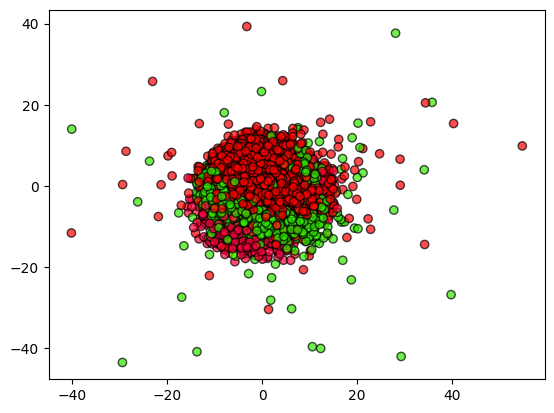

In [78]:
plt.scatter(X_train_mds[:, 0], X_train_mds[:, 1], c=y_train, cmap=plt.cm.prism, edgecolor='k', alpha=0.7)
plt.show()

In [79]:
#X_test_mds = mds.transform(X_test) # no transform

clf = DecisionTreeClassifier(min_samples_leaf=3, random_state=42)
clf.fit(X_train_mds, y_train)

y_pred = clf.predict(X_train_mds)

print('Accuracy %s' % accuracy_score(y_train, y_pred))
print('F1-score %s' % f1_score(y_train, y_pred, average=None))
print(classification_report(y_train, y_pred))

Accuracy 0.9381965552178319
F1-score [0.96450803 0.84894666 0.85209713 0.        ]
              precision    recall  f1-score   support

           0       0.96      0.97      0.96      4544
           1       0.87      0.83      0.85      1143
           2       0.87      0.83      0.85       232
           3       0.00      0.00      0.00         3

    accuracy                           0.94      5922
   macro avg       0.68      0.66      0.67      5922
weighted avg       0.94      0.94      0.94      5922



c:\Users\steve\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\steve\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\steve\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

## IsoMap

In [65]:
from sklearn.manifold import Isomap

In [127]:
iso = Isomap(n_components=2, n_neighbors=8) # n_neighbors=5 is the default, but it is important to specify it here to avoid a warning about future changes in the default value
X_train_iso = iso.fit_transform(X_train_scaled)
X_test_iso = iso.transform(X_test_scaled)
X_train_iso.shape

(5922, 2)

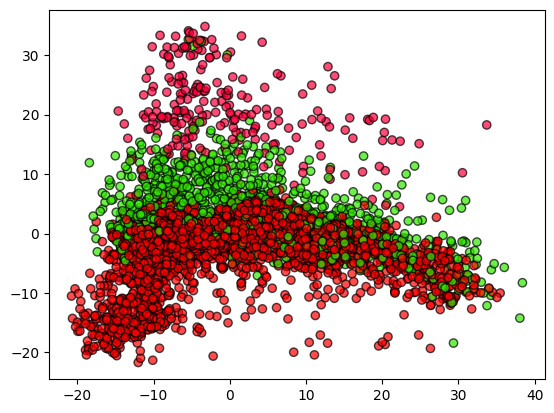

In [128]:
plt.scatter(X_train_iso[:, 0], X_train_iso[:, 1], c=y_train, cmap=plt.cm.prism, edgecolor='k', alpha=0.7)
plt.show()

In [129]:
clf = DecisionTreeClassifier(min_samples_leaf=3, random_state=42)
clf.fit(X_train_iso, y_train)

y_pred = clf.predict(X_test_iso)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

Accuracy 0.793144208037825
F1-score [0.87737042 0.4375     0.78947368 0.        ]
              precision    recall  f1-score   support

           0       0.86      0.89      0.88      1945
           1       0.47      0.41      0.44       493
           2       0.82      0.77      0.79        98
           3       0.00      0.00      0.00         2

    accuracy                           0.79      2538
   macro avg       0.54      0.52      0.53      2538
weighted avg       0.78      0.79      0.79      2538



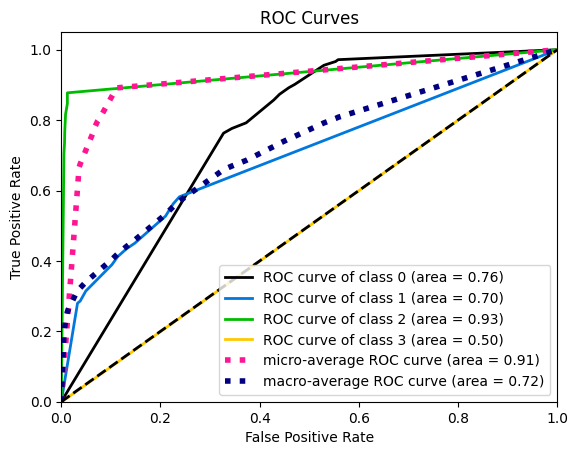

In [131]:
y_score = clf.predict_proba(X_test_iso)
plot_roc(y_test, y_score)
plt.show()

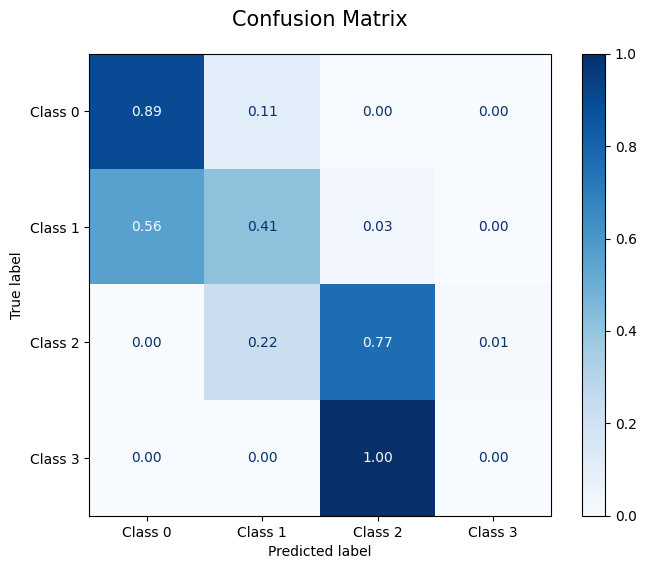

In [132]:
# 1. Crea la figura
fig, ax = plt.subplots(figsize=(8, 6))

# 2. Usa 'normalize=true' per vedere le percentuali per riga
# Usiamo 'Blues' o 'Viridis' per una migliore leggibilità
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    display_labels=["Class 0", "Class 1", "Class 2", "Class 3"], # Opzionale: nomi reali
    cmap=plt.cm.Blues,
    normalize='true', 
    ax=ax,
    values_format='.2f' # Mostra solo 2 decimali
)

# 3. Personalizzazione estetica
ax.set_title("Confusion Matrix", fontsize=15, pad=20)
plt.grid(False) # Rimuove linee fastidiose se presenti
plt.show()

## t-SNE

In [133]:
from sklearn.manifold import TSNE

In [134]:
tsne = TSNE(n_components=2)
X_train_tsne = tsne.fit_transform(X_train_scaled)
X_train_tsne.shape

(5922, 2)

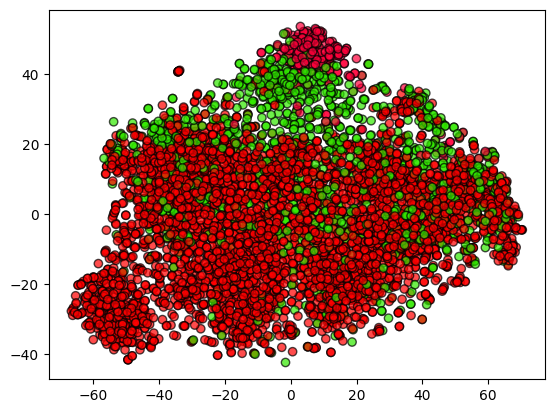

In [135]:
plt.scatter(X_train_tsne[:, 0], X_train_tsne[:, 1], c=y_train, cmap=plt.cm.prism, edgecolor='k', alpha=0.7)
plt.show()

In [136]:
#X_test_mds = mds.transform(X_test) # no transform

clf = DecisionTreeClassifier(min_samples_leaf=3, random_state=42)
clf.fit(X_train_tsne, y_train)

y_pred = clf.predict(X_train_tsne)

print('Accuracy %s' % accuracy_score(y_train, y_pred))
print('F1-score %s' % f1_score(y_train, y_pred, average=None))
print(classification_report(y_train, y_pred))

Accuracy 0.9356636271529889
F1-score [0.96208065 0.83518436 0.9086758  0.        ]
              precision    recall  f1-score   support

           0       0.95      0.97      0.96      4539
           1       0.85      0.82      0.84      1151
           2       0.95      0.87      0.91       228
           3       0.00      0.00      0.00         4

    accuracy                           0.94      5922
   macro avg       0.69      0.66      0.68      5922
weighted avg       0.93      0.94      0.93      5922

